# Movie Data Analysis and Recommender System

The birth of the motion picture camera in the late 19th century gave rise to arguably the most potent form of storytelling in existence: Cinema. Audiences have been enthralled by the medium’s evolution—from the 1890s "horse in motion" clips to the introduction of "talkies" in the 1920s, the arrival of Technicolor in the 1930s, and the mainstream 3D spectacles of the early 2010s.

While cinema had humble origins—constrained by technical limitations in plot and duration—it has since been shaped by generations of creative geniuses. Today, movie industries worldwide span a vast spectrum of genres, from poignant romances to mind-bending science fiction.

Like most children of the last century, I grew up captivated by the enigmatic world of film. This notebook is an attempt to translate that fascination into insight using data. Leveraging a dataset of approximately 45,000 movies from TMDB, I will explore the trends that define the industry and build three distinct models:

- __Revenue Regressor__: A model to predict the box office performance of a given film.

- __Success Classifier__: A tool to identify whether a movie will be a "hit" or a financial loss for producers.

- __Hybrid Recommendation System__: An engine combining popularity, content-based, and collaborative filtering (utilizing both TMDB and MovieLens data) to suggest the perfect film.

### Installing dependencies and loading data

In [1]:

%matplotlib inline
from IPython.display import Image, HTML
import json
import datetime
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from wordcloud import WordCloud, STOPWORDS

import plotly.express as px
import plotly.graph_objects as go

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.read_csv('movies_metadata.csv')
df.head()

C:\Users\sahaj\AppData\Local\Temp\ipykernel_25948\3991525872.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",NaN,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on selling their home, but that's a plan that -- like George -- will have to change with the arrival of both a grandchild and a kid of his own.",...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's In For The Surprise Of His Life!,Father of the Bride Part II,False,5.7,173.0


## Data Preprocessing

In [3]:
df = df.drop(['imdb_id'], axis =1)

In [4]:
df = df.drop('original_title', axis=1)

In [5]:
df[df['revenue'] == 0].shape

(38052, 22)

We see that the majority of the movies have a recorded revenue of __0__. This indicates that we do not have information about the total revenue for these movies. Although this forms the majority of the movies available to us, we will still use revenue as an extremely important feature going forward from the remaining 7000 moves.

In [6]:
df['revenue'] = df['revenue'].replace(0, np.nan)


The __budget__ feature has some unclean values that makes Pandas assign it as a generic object. We proceed to convert this into a numeric variable and replace all the non-numeric values with NaN. Finally, as with budget, we will convert all the values of 0 with NaN to indicate the absence of information regarding budget.

In [7]:
df['budget'] = pd.to_numeric(df['budget'], errors = 'coerce')
df['budget'] = df['budget'].replace(0, np.nan)
df[df['budget'].isnull()].shape

(36576, 22)

In [8]:
df[['revenue', 'budget']].head()

,revenue,budget
0,373554033.0,30000000.0
1,262797249.0,65000000.0
2,NaN,NaN
3,81452156.0,16000000.0
4,76578911.0,NaN



As we move forward trying to answer certain questions, we will have to construct several features suitable for that particular query. For now, we will construct two very important features:

- __year__: The year in which the movie was released.
- __return__: The ratio of revenue to budget.


The return feature is extremely insightful as it will give us a more accurate picture of the financial success of a movie. Presently, our data will not be able to judge if a  200 million budget movie that earned 100 million did better than a 50,000 budget movie taking in 200,000. This feature will be able to capture that information.

A return value > 1 would indicate profit whereas a return value < 1 would indicate a loss.

In [9]:
df['return'] = df['revenue'] / df['budget']
df[df['return'].isnull()].shape

(40085, 23)


We have close to __5000 movies__ for which we have data on revenue and budget ratio. This is close to __10% of the entire dataset__. Although this may seem small, this is enough to perform very useful analysis and discover interesting insights about the world of movies.

In [10]:
df['return'].sample(10)

12218    6.022777
16565         NaN
2192          NaN
41635         NaN
13339         NaN
30451         NaN
20173         NaN
30829         NaN
7903          NaN
12259         NaN
Name: return, dtype: float64

In [11]:
df['release_date'].head()

0    1995-10-30
1    1995-12-15
2    1995-12-22
3    1995-12-22
4    1995-02-10
Name: release_date, dtype: object

In [12]:
df['year'] = pd.to_datetime(df['release_date'], errors = 'coerce').apply(lambda x: str(x).split('-')[0] if x != np.nan else np.nan)

In [13]:
df['year'].head()

0    1995
1    1995
2    1995
3    1995
4    1995
Name: year, dtype: object

In [14]:
df['adult'].value_counts()

adult
False                                                                                                                             45454
True                                                                                                                                  9
 - Written by Ørnås                                                                                                                   1
 Rune Balot goes to a casino connected to the October corporation to try to wrap up her case once and for all.                        1
 Avalanche Sharks tells the story of a bikini contest that turns into a horrifying affair when it is hit by a shark avalanche.        1
Name: count, dtype: int64

There are close to __0 adult movies__ in this dataset. The __adult__ feature therefore is not of much use to us and can be safely dropped.

In [15]:
df = df.drop('adult', axis=1)

In [16]:
base_poster_url = 'http://image.tmdb.org/t/p/w185/'
df['poster_path'] = "<img src='" + base_poster_url + df['poster_path'] + "' style='height:100px;'>"

In [17]:
df['title'] = df['title'].astype('str')
df['overview'] = df['overview'].astype('str')

In [18]:
df['production_countries'] = df['production_countries'].fillna('[]').apply(ast.literal_eval)

In [19]:
df['production_countries'] = df['production_countries'].apply(lambda x: [i['name'] for i in x]
                                                              if isinstance(x, list)
                                                              else[])

In [20]:
df['original_language'].drop_duplicates().shape[0]

93

In [21]:
def clean_numeric(x):
    try:
        return float(x)
    except:
        return np.nan

In [22]:
df[['popularity', 'vote_count', 'vote_average']].isnull().sum()

popularity      5
vote_count      6
vote_average    6
dtype: int64

In [23]:
df['popularity'] = df['popularity'].apply(clean_numeric).astype('float')
df['vote_count'] = df['vote_count'].apply(clean_numeric).astype('float')
df['vote_average'] = df['vote_average'].apply(clean_numeric).astype('float')

In [24]:

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

In [25]:
def get_month(x):
    try:
        return month_order[int(str(x).split('-')[1]) - 1]
    except:
        return np.nan

In [26]:

def get_day(x):
    try:
        year, month, day = (int(i) for i in x.split('-'))    
        answer = datetime.date(year, month, day).weekday()
        return day_order[answer]
    except:
        return np.nan

In [27]:
#Alternate way
#datetime.date(2026, 6 , 14).strftime('%A')

In [28]:
df['day'] = df['release_date'].apply(get_day)
df['month'] = df['release_date'].apply(get_month)

With these features in hand, let us now check the most popular and most successful months and days.

In [29]:

credits_df = pd.read_csv('credits.csv')
credits_df.head()

cast  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         [{'cast_id': 14, 'character': 'Woody (voice)', 'credit_id': '52fe4284c3a36847f8024f95', 'gender': 2, 'id': 31, 'name': 'Tom Hanks', 'order': 0, 'profile_path': '/pQFoyx7rp09CJTAb932F2g8Nlho.jpg'}, {'cast_id': 15, 'character': 'Buzz Lightyear (voice)', 'credit_id': '52fe4284c3a36847f8024f99', 'gender': 2, 'id': 12898, 'name': 'Tim Allen', 'order': 1, 'profile_path': '/uX2xVf6pMmPepxnvFWyBtjexzgY.jpg'}, {'cast_id': 16, 'character': 'Mr. Potato Head (voice)', 'credit_id': '52fe4284c3a36847f8024f9d', 'gender': 2, 'id': 7167, 'name': 'Don Rickles', 'order': 2, 'profile_path': '/h5BcaDMPRVLHLDzbQavec4xfSdt.jpg'}, {'cast_id': 17, 'character': 'Slinky Dog (voice)', 'credit_id': '52fe4284c3a36847f8024fa1', 'gender': 2, 'id': 12899, 'name': 'Jim Varney', 'order': 3, 'profile_path': '/eIo2jVVXYgjDtaHoF19Ll9vtW7h.jpg'}, {'cast_id': 18, 'character': 'Rex (voice)', 'credit_id': '52fe4284c3a36847f8024fa5', 'gender': 2, 'id': 12900, 'name': 'Wallace Shawn', 'order': 4, 'profile_path': '/oGE6JqPP2xH4tNORKNqxbNPYi7u.jpg'}, {'cast_id': 19, 'character': 'Hamm (voice)', 'credit_id': '52fe4284c3a36847f8024fa9', 'gender': 2, 'id': 7907, 'name': 'John Ratzenberger', 'order': 5, 'profile_path': '/yGechiKWL6TJDfVE2KPSJYqdMsY.jpg'}, {'cast_id': 20, 'character': 'Bo Peep (voice)', 'credit_id': '52fe4284c3a36847f8024fad', 'gender': 1, 'id': 8873, 'name': 'Annie Potts', 'order': 6, 'profile_path': '/eryXT84RL41jHSJcMy4kS3u9y6w.jpg'}, {'cast_id': 26, 'character': 'Andy (voice)', 'credit_id': '52fe4284c3a36847f8024fc1', 'gender': 0, 'id': 1116442, 'name': 'John Morris', 'order': 7, 'profile_path': '/vYG

In [30]:
def convert_int(x):
    try:
        return int(x)
    except:
        return np.nan

In [31]:
df['id'] = df['id'].apply(convert_int)

In [32]:
df[df['id'].isnull()]

,belongs_to_collection,budget,genres,homepage,id,original_language,overview,popularity,poster_path,production_companies,...,status,tagline,title,video,vote_average,vote_count,return,year,day,month
19730,0.065736,NaN,"[{'name': 'Carousel Productions', 'id': 11176}, {'name': 'Vision View Entertainment', 'id': 11602}, {'name': 'Telescene Film Group Productions', 'id': 29812}]","[{'iso_3166_1': 'CA', 'name': 'Canada'}, {'iso_3166_1': 'LU', 'name': 'Luxembourg'}, {'iso_3166_1': 'GB', 'name': 'United Kingdom'}, {'iso_3166_1': 'US', 'name': 'United States of America'}]",NaN,104.0,Released,NaN,<img src='http://image.tmdb.org/t/p/w185/Midnight Man' style='height:100px;'>,False,...,NaN,NaN,nan,NaN,NaN,NaN,NaN,NaT,NaN,NaN
29503,1.931659,NaN,"[{'name': 'Aniplex', 'id': 2883}, {'name': 'GoHands', 'id': 7759}, {'name': 'BROSTA TV', 'id': 7760}, {'name': 'Mardock Scramble Production Committee', 'id': 7761}, {'name': 'Sentai Filmworks', 'id': 33751}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}, {'iso_3166_1': 'JP', 'name': 'Japan'}]",NaN,68.0,Released,NaN,<img src='http://image.tmdb.org/t/p/w185/Mardock Scramble: The Third Exhaust' style='height:100px;'>,False,...,NaN,NaN,nan,NaN,NaN,NaN,NaN,NaT,NaN,NaN
35587,2.185485,NaN,"[{'name': 'Odyssey Media', 'id': 17161}, {'name': 'Pulser Productions', 'id': 18012}, {'name': 'Rogue State', 'id': 18013}, {'name': 'The Cartel', 'id': 23822}]","[{'iso_3166_1': 'CA', 'name': 'Canada'}]",NaN,82.0,Released,NaN,<img src='http://image.tmdb.org/t/p/w185/Avalanche Sharks' style='height:100px;'>,False,...,NaN,NaN,nan,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [33]:
df = df.drop([35587, 29503, 19730])

In [34]:
df['id'] = df['id'].astype('int')

In [35]:
df = df.merge(credits_df, on='id')
df.shape

(45538, 27)

In [36]:
df['cast'] = df['cast'].apply(ast.literal_eval)
df['crew'] = df['crew'].apply(ast.literal_eval)

In [37]:
df['cast_size'] = df['cast'].apply(lambda x: len(x))
df['crew_size'] = df['crew'].apply(lambda x: len(x))
df.shape

(45538, 29)

In [38]:
df['cast'] = df['cast'].apply(lambda x: [i['name'] for i in x]
                              if isinstance(x, list) 
                              else [])

In [39]:
def get_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
        else:
            return np.nan

In [40]:
df['Director'] = df['crew'].apply(get_director)
df.shape

(45538, 30)

In [41]:
df['genres'] = df['genres'].fillna('[]').apply(ast.literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [47]:
df['belongs_to_collection'].sample(10)

6238     {'id': 34055, 'name': 'Pokémon Collection', 'poster_path': '/j5te0YNZAMXDBnsqTUDKIBEt8iu.jpg', 'backdrop_path': '/iGoYKA0TFfgSoZpG2u5viTJMGfK.jpg'}
17050                                                                                                                                                    NaN
28037                                                                                                                                                    NaN
35561                                                                                                                                                    NaN
30365                                                                                                                                                    NaN
24306                                           {'id': 312744, 'name': 'Madicken', 'poster_path': '/7EQK8pI2sWZCexDD5YBhtXpLU0N.jpg', 'backdrop_path': None}
28551                                                     

In [49]:
def extract_collection_name(x):
    if pd.isna(x):
        return np.nan

    if isinstance(x, str):
        x = ast.literal_eval(x)

    return x.get('name') if isinstance(x, dict) else np.nan


df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    extract_collection_name
)

In [50]:
df['production_companies'] = df['production_companies'].fillna('[]').apply(ast.literal_eval).apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

In [51]:
df = df.drop(['crew'], axis = 1)

In [52]:
df.head(1)

,belongs_to_collection,budget,genres,homepage,id,original_language,overview,popularity,poster_path,production_companies,...,vote_average,vote_count,return,year,day,month,cast,cast_size,crew_size,Director
0,Toy Story Collection,30000000.0,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,en,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",21.946943,<img src='http://image.tmdb.org/t/p/w185//rhIRbceoE9lR4veEXuwCC2wARtG.jpg' style='height:100px;'>,[Pixar Animation Studios],...,7.7,5415.0,12.451801,1995,Mon,Oct,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney, Wallace Shawn, John Ratzenberger, Annie Potts, John Morris, Erik von Detten, Laurie Metcalf, R. Lee Ermey, Sarah Freeman, Penn Jillette]",13,106,John Lasseter


## Regression: Predicting Movie Revenues

In this section, I will attempt at building a regression model to predict movie revenues. Since this isn't one of the main goals of this project, I will not spend too much time feature engineering or hyperparamater tuning my model.

Predicting Movie Revenues is an extremely popular problem in Machine Learning which has created a huge amount of literature. Most of the models proposed in these papers use far more potent features than what we possess at the moment. These include Facebook Page Likes, Information on Tweets about the Movie, YouTube Trailer Reaction (Views, Likes, Dislikes, etc.), Movie Rating (MPCAA, CBIFC) among many others.

To compensate for the lack of these features, we are going to cheat a little. We will be using TMDB's __Popularity Score__ and __Vote Average__ as our features in our model to assign a nuerical value to popularity. However, it must be kept in mind that these metrics will not be available when predicting movie revenues in the real world, when the movie has not been released yet.

In [53]:
rgf = df[df['return'].notnull()]
rgf.shape

(5393, 29)


We have 5393 records in our training set. Let us take a look at the features we possess and remove the ones which are unnecessary.

In [54]:
rgf.columns

Index(['belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'original_language', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'return', 'year', 'day', 'month',
       'cast', 'cast_size', 'crew_size', 'Director'],
      dtype='object')

In [55]:
rgf = rgf.drop(['id', 'overview', 'poster_path', 'release_date', 'status', 'tagline', 'video', 'return'], axis=1)


In [56]:
rgf.head(1)

,belongs_to_collection,budget,genres,homepage,original_language,popularity,production_companies,production_countries,revenue,runtime,...,title,vote_average,vote_count,year,day,month,cast,cast_size,crew_size,Director
0,Toy Story Collection,30000000.0,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,en,21.946943,[Pixar Animation Studios],[United States of America],373554033.0,81.0,...,Toy Story,7.7,5415.0,1995,Mon,Oct,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney, Wallace Shawn, John Ratzenberger, Annie Potts, John Morris, Erik von Detten, Laurie Metcalf, R. Lee Ermey, Sarah Freeman, Penn Jillette]",13,106,John Lasseter


### Feature Engineering

We will perform the following feature engineering tasks:

belongs_to_collection will be turned into a Boolean variable. 1 indicates a movie is a part of collection whereas 0 indicates it is not.  
genres will be converted into number of genres.    
homepage will be converted into a Boolean variable that will indicate if a movie has a homepage or not.  
original_language will be replaced by a feature called is_foreign to denote if a particular film is in English or a Foreign Language.  
production_companies will be replaced with just the number of production companies collaborating to make the movie.      
production_countries will be replaced with the number of countries the film was shot in.  
day will be converted into a binary feature to indicate if the film was released on a Friday.  
month will be converted into a variable that indicates if the month was a holiday season.  

In [57]:

s = rgf.apply(lambda x: pd.Series(x['genres']),axis=1).stack().reset_index(level=1, drop=True)
s.name = 'genre'
gen_rgf = rgf.drop('genres', axis=1).join(s)
genres_train = gen_rgf['genre'].drop_duplicates()

In [58]:
def feature_engineering(df):
    df = df.copy()

    # Collection exists?
    df['belongs_to_collection'] = (df['belongs_to_collection'].notna().astype(int))

    # Genre indicators
    for genre in genres_train:
        df[f'is_{genre}'] = df['genres'].apply(
            lambda x: int(genre in x) if isinstance(x, list) else 0
        )

    # Number of genres
    df['genres'] = df['genres'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    # Homepage exists?
    df['homepage'] = df['homepage'].notna().astype(int)

    # English language movie?
    df['is_english'] = (df['original_language'] == 'en').astype(int)

    # Number of companies/countries
    df['production_companies'] = df['production_companies'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    df['production_countries'] = df['production_countries'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    # Friday release?
    df['is_Friday'] = (df['day'] == 'Fri').astype(int)

    # Holiday season release?
    df['is_Holiday'] = df['month'].isin(
        ['Apr', 'May', 'Jun', 'Dec']
    ).astype(int)

    # Drop unused columns
    df.drop(
        columns=[
            'original_language',
            'spoken_languages',
            'day',
            'month',
            'year',
            'title',
            'cast',
            'Director'
        ],
        inplace=True,
        errors='ignore'
    )

    # One-hot encode remaining categorical variables
    df = pd.get_dummies(df, prefix='is', drop_first=True)

    # Fill missing numerical values
    df['runtime'] = df['runtime'].fillna(
        df['runtime'].mean()
    )

    df['vote_average'] = df['vote_average'].fillna(
        df['vote_average'].mean()
    )

    return df

In [59]:
X = rgf.drop('revenue', axis=1)
y = rgf['revenue']

In [60]:
X = feature_engineering(X)

In [61]:
X.head()

,belongs_to_collection,budget,genres,homepage,popularity,production_companies,production_countries,runtime,vote_average,vote_count,...,is_War,is_Foreign,is_Documentary,is_Western,is_Music,is_nan,is_TV Movie,is_english,is_Friday,is_Holiday
0,1,30000000.0,3,1,21.946943,1,1,81.0,7.7,5415.0,...,0,0,0,0,0,0,0,1,0,0
1,0,65000000.0,3,0,17.015539,3,1,104.0,6.9,2413.0,...,0,0,0,0,0,0,0,1,1,1
3,0,16000000.0,3,0,3.859495,1,1,127.0,6.1,34.0,...,0,0,0,0,0,0,0,1,1,1
5,0,60000000.0,4,0,17.924927,3,1,170.0,7.7,1886.0,...,0,0,0,0,0,0,0,1,1,1
8,0,35000000.0,3,0,5.231580,3,1,106.0,5.5,174.0,...,0,0,0,0,0,0,0,1,1,1


In [62]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, train_size=0.75, test_size=0.25)

In [63]:
X.shape

(5393, 36)

In [64]:
reg = GradientBoostingRegressor()
reg.fit(train_X, train_y)
reg.score(test_X, test_y)

0.7879658702528065


We get a Coefficient of Determination of 0.78 which is a pretty score for the basic model that we have built. Let us compare our model's score to a Dummy Regressor.

In [65]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor()
dummy.fit(train_X, train_y)
dummy.score(test_X, test_y)

-0.004195944069144586


We see that our model performs far more superiorly than the Dummy Regressor. Finally, let us plot the feature importances in the form of a bar plot to deduce which features were the most significant in our making predictions.

<Axes: ylabel='None'>

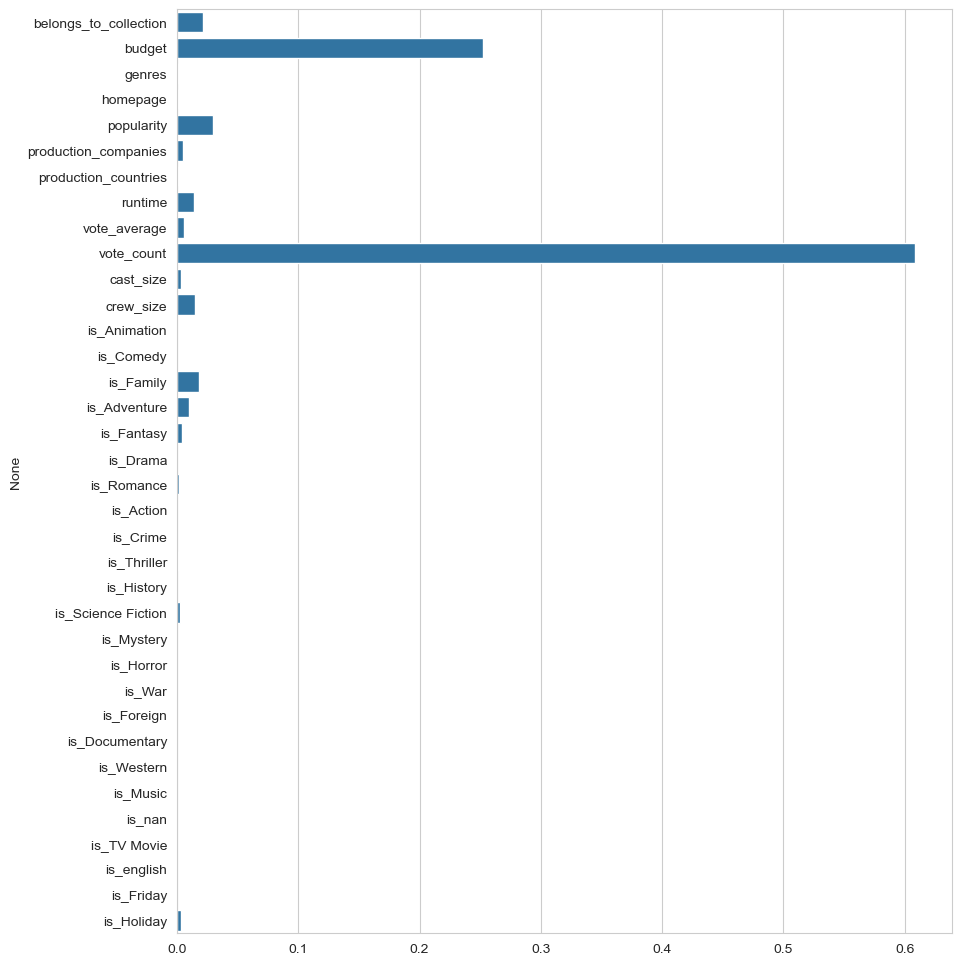

In [66]:

sns.set_style('whitegrid')
plt.figure(figsize=(10,12))
sns.barplot(x=reg.feature_importances_, y=X.columns)

<Axes: ylabel='None'>

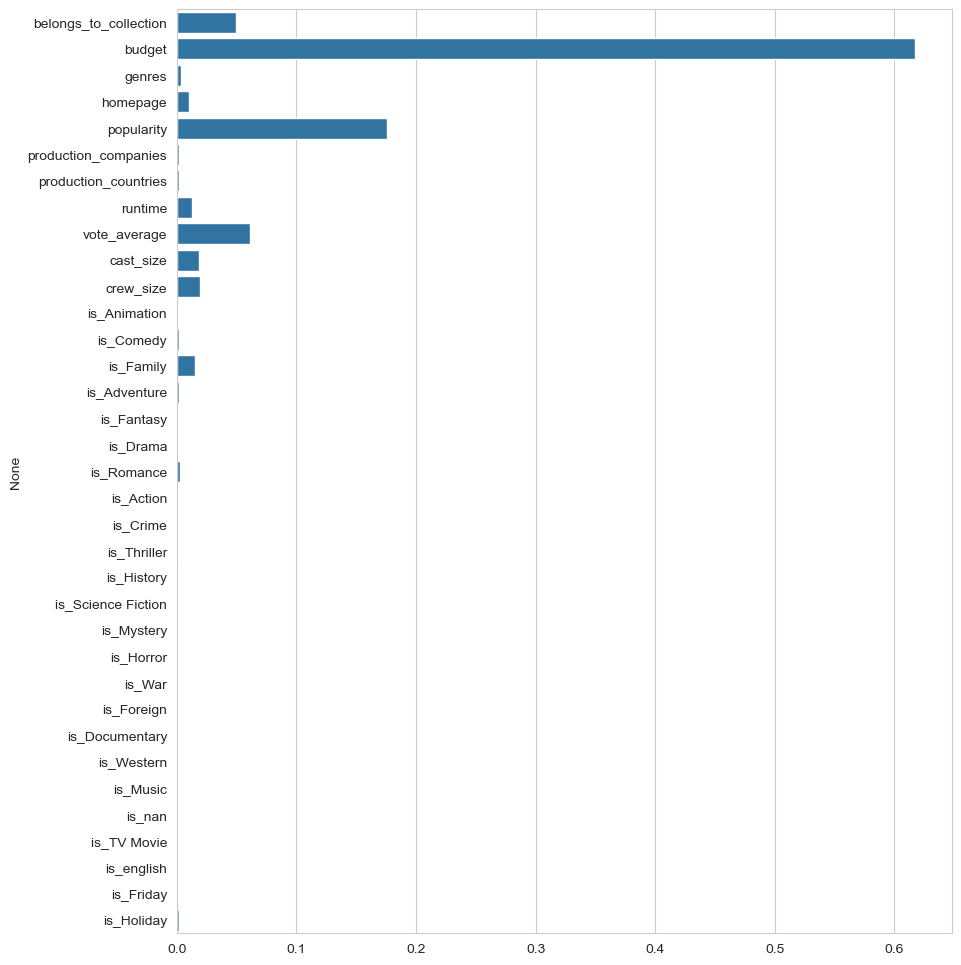

In [67]:
#Dropping the vote_count factor and redoing the whole thing:

X2 = X.drop(['vote_count'], axis=1)
y2 = y
train_X2, test_X2, train_y2, test_y2 = train_test_split(X2, y2, train_size=0.75, test_size=0.25)

reg2 = GradientBoostingRegressor()
reg2.fit(train_X2, train_y2)

sns.set_style('whitegrid')
plt.figure(figsize=(10,12))
sns.barplot(x=reg2.feature_importances_, y=X2.columns)

In summary, we notice that __vote_count__, a feature we cheated with, is the most important feature to our Gradient Boosting Model. This goes on to show the improtance of popularity metrics in determining the revenue of a movie. __Budget__ was the second most important feature followed by __Popularity__ (Literally, a popularity metric) and __Crew Size__.

## Classification: Predicting Movie Sucess
What factors influence whether a movie will be able to recoup its investments? I will try to answer this question by building a binary classifier that predicts if a movie will make a profit or a loss. As with our regression model, we will cheat a little and use features that may not be available to us in the real world for the lack of other useful popularity metrics.

We have already performed extensive analysis of our data and haven't done a lot with respect to determining factors that make a movie a success. We shall attempt at doing that in this section and follow it up by building our model.

In [128]:
cls = df[df['return'].notnull()]
cls.shape

(5393, 29)

In [129]:
cls.columns

Index(['belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'original_language', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'return', 'year', 'day', 'month',
       'cast', 'cast_size', 'crew_size', 'Director'],
      dtype='object')

Let us convert our return feature into a binary variable that will serve as our classes: 0 indicating a flop and 1 indicating a hit.

In [130]:
cls = cls.copy()

cls['return'] = (cls['return'] >= 1).astype(int)

In [131]:
cls['return'].value_counts()

return
1    3784
0    1609
Name: count, dtype: int64

Our classes seem to be fairly balanced. We do not need to apply any additional methods to deal with the imbalance of classes. Let us now turn our attention to our features.

In [132]:
df['belongs_to_collection'].notnull().sum()

np.int64(4500)

In [133]:
cls['belongs_to_collection'].duplicated().sum()

np.int64(4755)

In [134]:
cls['belongs_to_collection'] = (
    cls['belongs_to_collection'].notna().astype(int)
)

In [135]:
cls['belongs_to_collection'].sample(10)

3916     0
1515     0
11711    0
3506     1
32552    0
3065     1
21057    0
10825    0
651      0
2322     0
Name: belongs_to_collection, dtype: int64

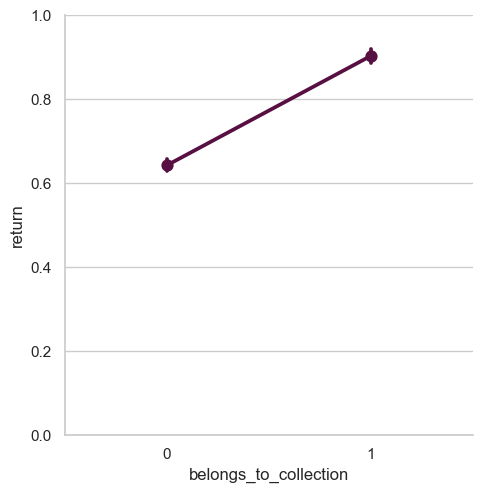

In [136]:
sns.set(style="whitegrid")
g = sns.PairGrid(data=cls, x_vars=['belongs_to_collection'], y_vars='return', height=5)
g.map(sns.pointplot, color=sns.xkcd_rgb["plum"])
g.set(ylim=(0, 1))

It seems that movies that belong to a franchise have a higher probability of being a success.

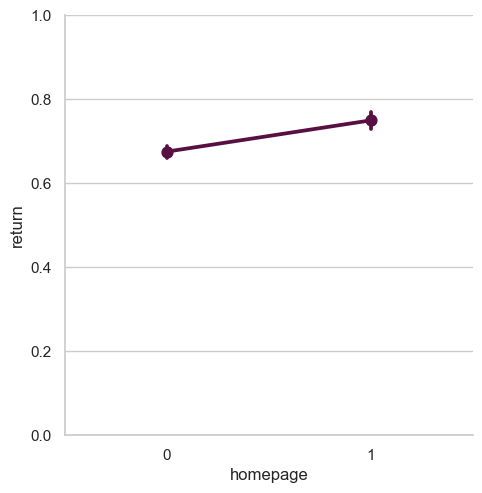

In [137]:
cls['homepage'] = cls['homepage'].fillna('').apply(lambda x: 0 if x == '' else 1)
g = sns.PairGrid(data=cls, x_vars=['homepage'], y_vars='return', height=5)
g.map(sns.pointplot, color=sns.xkcd_rgb["plum"])
g.set(ylim=(0, 1))


We see that with homepages, there is not a very huge difference in probability. To avoid the curse of dimensionality, we will eliminate this feature as it is not very useful.

In [138]:
s = cls.apply(lambda x: pd.Series(x['genres']),axis=1).stack().reset_index(level=1, drop=True)
s.name = 'genre'
gen_cls = cls.drop('genres', axis=1).join(s)

<Axes: xlabel='genre'>

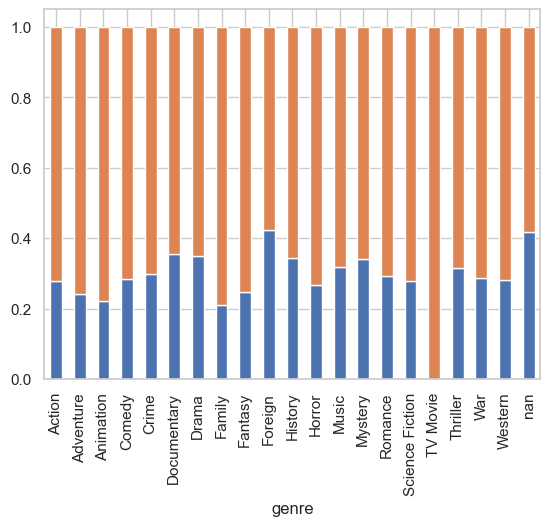

In [139]:
ctab = pd.crosstab([gen_cls['genre']], gen_cls['return'], dropna=False).apply(lambda x: x/x.sum(), axis=1)
ctab.plot(kind='bar', stacked=True, legend=False)

We find that __TV Movies__ have a 0% Failure Rate but that is most probably because they are extremely few in numner. __Foreign Films__ have a higher rate of failure than average. Since there isn't anything drastic about a particular genre, we will proceed with one hot encoding all genres.

In [140]:
cls.columns

Index(['belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'original_language', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'return', 'year', 'day', 'month',
       'cast', 'cast_size', 'crew_size', 'Director'],
      dtype='object')

### Classification Engineering

In [141]:
cls = cls.drop(['id', 'overview', 'poster_path', 'release_date',
       'revenue', 'status', 'tagline'], axis=1)

In [142]:
cls.columns

Index(['belongs_to_collection', 'budget', 'genres', 'homepage',
       'original_language', 'popularity', 'production_companies',
       'production_countries', 'runtime', 'spoken_languages', 'title', 'video',
       'vote_average', 'vote_count', 'return', 'year', 'day', 'month', 'cast',
       'cast_size', 'crew_size', 'Director'],
      dtype='object')

In [152]:
def classification_engineering(df):
    df = df.copy()

    # Genre indicator variables
    for genre in genres_train:
        df[f'is_{genre}'] = df['genres'].apply(
            lambda x: int(genre in x) if isinstance(x, list) else 0
        )

    # Number of genres
    df['genres'] = df['genres'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    # English language flag
    df['is_english'] = (
        df['original_language'] == 'en'
    ).astype(int)

    # Number of production companies
    df['production_companies'] = df['production_companies'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    # Number of production countries
    df['production_countries'] = df['production_countries'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    # Friday release flag
    df['is_Friday'] = (
        df['day'] == 'Fri'
    ).astype(int)

    # Holiday season release flag
    df['is_Holiday'] = (
        df['month'].isin(['Apr', 'May', 'Jun', 'Dec'])
    ).astype(int)

    # Fill missing numeric values
    df['runtime'] = df['runtime'].fillna(
        df['runtime'].mean()
    )

    df['vote_average'] = df['vote_average'].fillna(
        df['vote_average'].mean()
    )

    # Remove unused columns
    df.drop(
        columns=[
            'homepage',
            'original_language',
            'year',
            'day',
            'month',
            'title',
            'cast',
            'Director',
            'spoken_languages'
        ],
        inplace=True,
        errors='ignore'
    )

    return df

In [153]:
cls2 = classification_engineering(cls)
cls2.columns

Index(['belongs_to_collection', 'budget', 'genres', 'popularity',
       'production_companies', 'production_countries', 'runtime', 'video',
       'vote_average', 'vote_count', 'return', 'cast_size', 'crew_size',
       'is_Animation', 'is_Comedy', 'is_Family', 'is_Adventure', 'is_Fantasy',
       'is_Drama', 'is_Romance', 'is_Action', 'is_Crime', 'is_Thriller',
       'is_History', 'is_Science Fiction', 'is_Mystery', 'is_Horror', 'is_War',
       'is_Foreign', 'is_Documentary', 'is_Western', 'is_Music', 'is_nan',
       'is_TV Movie', 'is_english', 'is_Friday', 'is_Holiday'],
      dtype='object')

In [154]:
X, y = cls2.drop('return', axis=1), cls['return']

In [155]:
X.head()

,belongs_to_collection,budget,genres,popularity,production_companies,production_countries,runtime,video,vote_average,vote_count,...,is_War,is_Foreign,is_Documentary,is_Western,is_Music,is_nan,is_TV Movie,is_english,is_Friday,is_Holiday
0,1,30000000.0,3,21.946943,1,1,81.0,False,7.7,5415.0,...,0,0,0,0,0,0,0,1,0,0
1,0,65000000.0,3,17.015539,3,1,104.0,False,6.9,2413.0,...,0,0,0,0,0,0,0,1,1,1
3,0,16000000.0,3,3.859495,1,1,127.0,False,6.1,34.0,...,0,0,0,0,0,0,0,1,1,1
5,0,60000000.0,4,17.924927,3,1,170.0,False,7.7,1886.0,...,0,0,0,0,0,0,0,1,1,1
8,0,35000000.0,3,5.231580,3,1,106.0,False,5.5,174.0,...,0,0,0,0,0,0,0,1,1,1


In [156]:
train_X, test_X, train_y, test_y = train_test_split(X, y, train_size=0.75, test_size=0.25, stratify=y)

In [157]:
clf = GradientBoostingClassifier()
clf.fit(train_X, train_y)
clf.score(test_X, test_y)

0.7909562638991846


Our basic Gradient Boosting Classifier has an accuracy of 80%. Again, this model can be improved upon through hyperparameter tuning and more advanced feature engineering but since this is not the main objective of this project, I will skip this.

In [159]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(train_X, train_y)
dummy.score(test_X, test_y)

0.7020014825796886

<Axes: ylabel='None'>

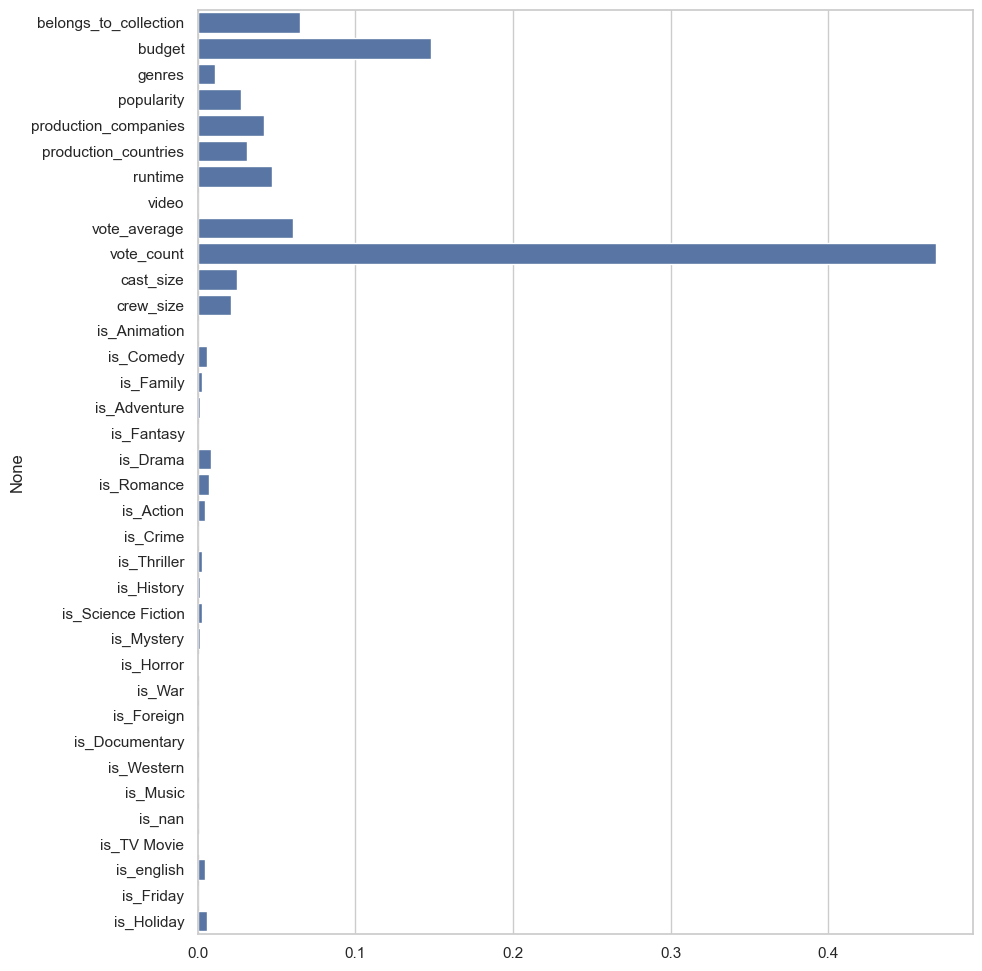

In [160]:
plt.figure(figsize=(10,12))
sns.barplot(x=clf.feature_importances_, y=X.columns)


We see that __Vote Count__ is once again the most significant feature identified by our Classifier. Other important features include __Budget, Popularity__ and __Year__. With this, we will conclude our discussion on the classification model and move on to the main part of the project.

In the next notebook, I will try to build a __Hybrid Recommendation System__ based on popularity, content and collaborative filtering. This will use the MovieLens dataset in addition to the TMDB Movies Metadata that we have used here.